
# Predicción de Fallas en Equipos - Aprendizaje Automático
### Villalba Brenda


## Introducción

En el presente trabajo se aborda el desarrollo de un modelo de aprendizaje automático orientado a la predicción de fallas en equipos industriales.

El objetivo principal es analizar el comportamiento de diversas variables operativas para identificar patrones que permitan anticipar la ocurrencia de fallas, contribuyendo a mejorar la toma de decisiones en contextos de mantenimiento preventivo y soporte técnico.

Para ello, se utilizará un dataset de mantenimiento predictivo, sobre el cual se realizará un análisis exploratorio de datos, un proceso de preparación y la implementación de modelos de clasificación.

---

## Descripción del Dataset y Origen

### 1. Descripción del Dataset

El dataset utilizado corresponde al AI4I 2020 Predictive Maintenance Dataset, el cual contiene información sobre el funcionamiento de equipos industriales bajo distintas condiciones operativas.

Su objetivo es permitir el análisis del comportamiento de las máquinas y la predicción de fallas a partir de variables relacionadas con el desempeño y desgaste de los equipos.


### Estructura del dataset

- Cantidad de registros (filas): 10.000  
- Cantidad de variables (columnas): 14  


### Variables principales

El dataset incluye diferentes tipos de variables relevantes para el análisis:

**Variables operativas:**

- `Air temperature [K]`: Temperatura del aire  
- `Process temperature [K]`: Temperatura del proceso  
- `Rotational speed [rpm]`: Velocidad de rotación  
- `Torque [Nm]`: Torque aplicado  
- `Tool wear [min]`: Desgaste de la herramienta  

**Variables categóricas:**

- `Type`: Tipo de producto (L, M, H)

**Identificadores:**

- `UDI`: Identificador único del registro  
- `Product ID`: Identificador del producto  

**Variables de fallas:**

- `Machine failure`: Indica si ocurrió una falla en el equipo  
- `TWF`: Tool Wear Failure  
- `HDF`: Heat Dissipation Failure  
- `PWF`: Power Failure  
- `OSF`: Overstrain Failure  
- `RNF`: Random Failures  

### Tipos de datos

El dataset contiene distintos tipos de variables:

- **Numéricas:** temperaturas, velocidad, torque, desgaste  
- **Categóricas:** tipo de producto  
- **Binarias:** indicadores de falla (0 = no, 1 = sí)  


### 2. Origen del Dataset

El dataset fue obtenido de la plataforma Kaggle, a partir del repositorio:

https://www.kaggle.com/code/jiejiea/ai4i-2020-predictive-maintenance/input

Este conjunto de datos fue diseñado con fines educativos y de investigación en el área de mantenimiento predictivo e inteligencia artificial.


### 3. Proceso de adquisición

El proceso de obtención y preparación inicial del dataset consistió en:

1. Descarga del archivo en formato CSV desde Kaggle  
2. Almacenamiento del dataset en el entorno local del proyecto  
3. Organización dentro de la estructura del proyecto en la carpeta correspondiente a datos procesados (`data/processed`)  


A partir de esta base, se procede al análisis exploratorio de los datos para identificar patrones, relaciones entre variables y su posible impacto en la ocurrencia de fallas.

## Comprensión del Dataset

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



df = pd.read_csv("../data/processed/ai4i2020.csv")
df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Distribución de Variables

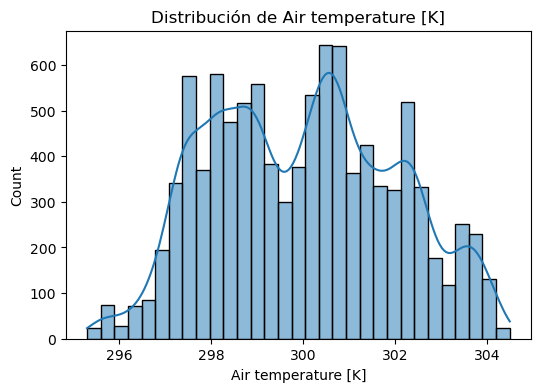

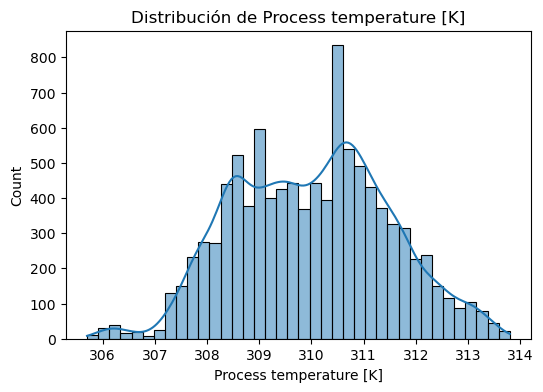

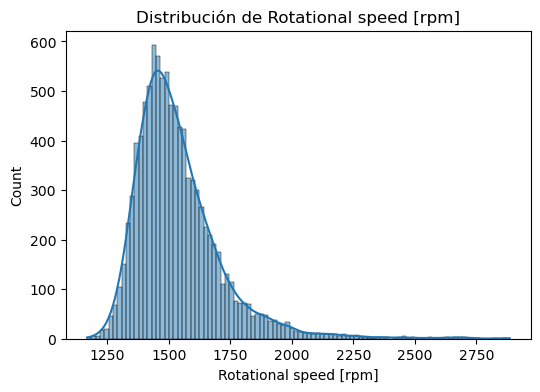

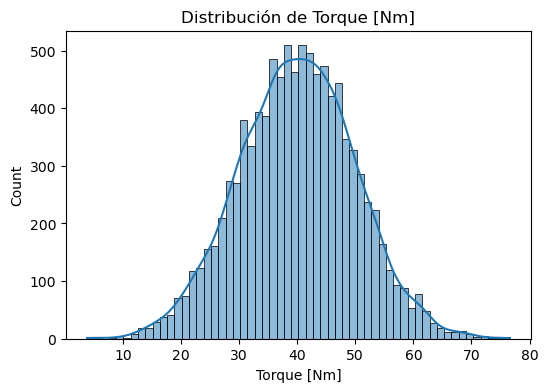

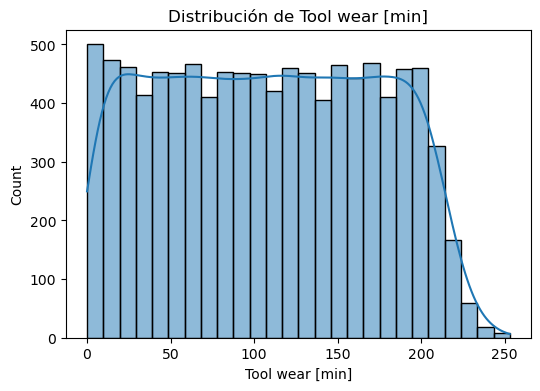

In [2]:
variables = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for var in variables:
    plt.figure(figsize=(6,4))
    sns.histplot(df[var], kde=True)
    plt.title(f"Distribución de {var}")
    plt.show()


Se analizaron las distribuciones de las variables operativas, observándose diferencias en su dispersión y comportamiento. 
Algunas variables presentan distribuciones más concentradas, mientras que otras evidencian mayor variabilidad, lo cual puede influir en la capacidad de los modelos para detectar patrones asociados a fallas.


### Relación entre Variables y la Falla

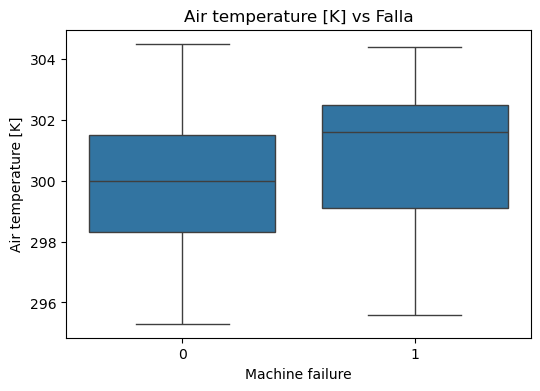

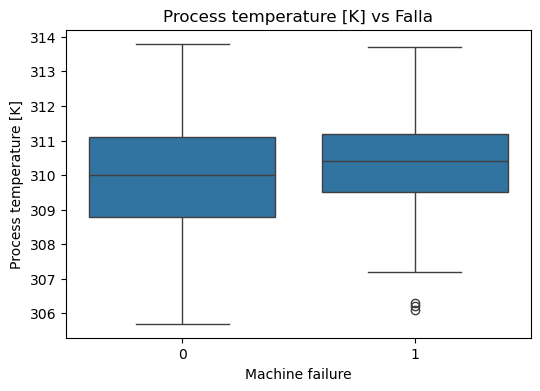

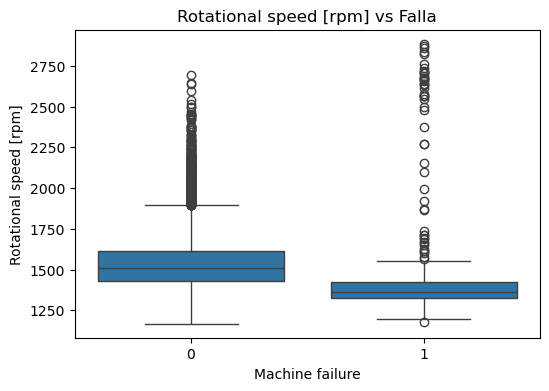

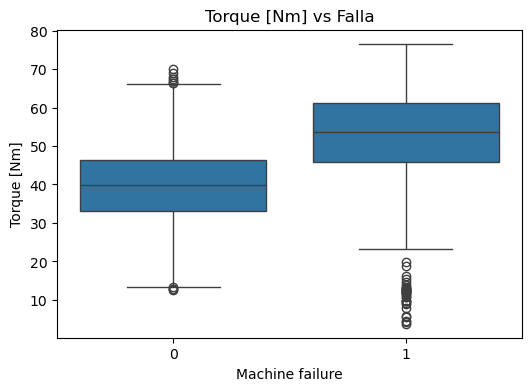

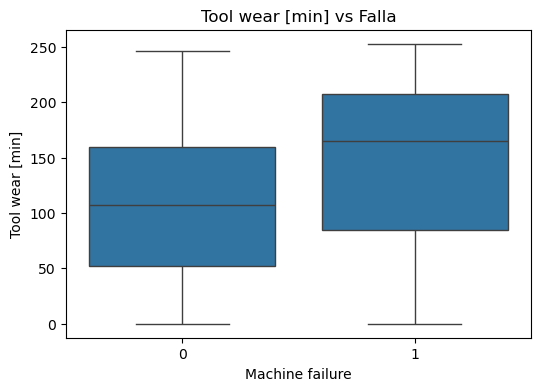

In [3]:
for var in variables:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Machine failure", y=var, data=df)
    plt.title(f"{var} vs Falla")
    plt.show()


Se analizó la relación entre las variables operativas y la ocurrencia de fallas mediante gráficos de caja.
Se observa que variables como el torque y el desgaste de la herramienta presentan diferencias más marcadas entre los casos con y sin falla, lo que sugiere su relevancia en la predicción.


### Matriz de Correlación

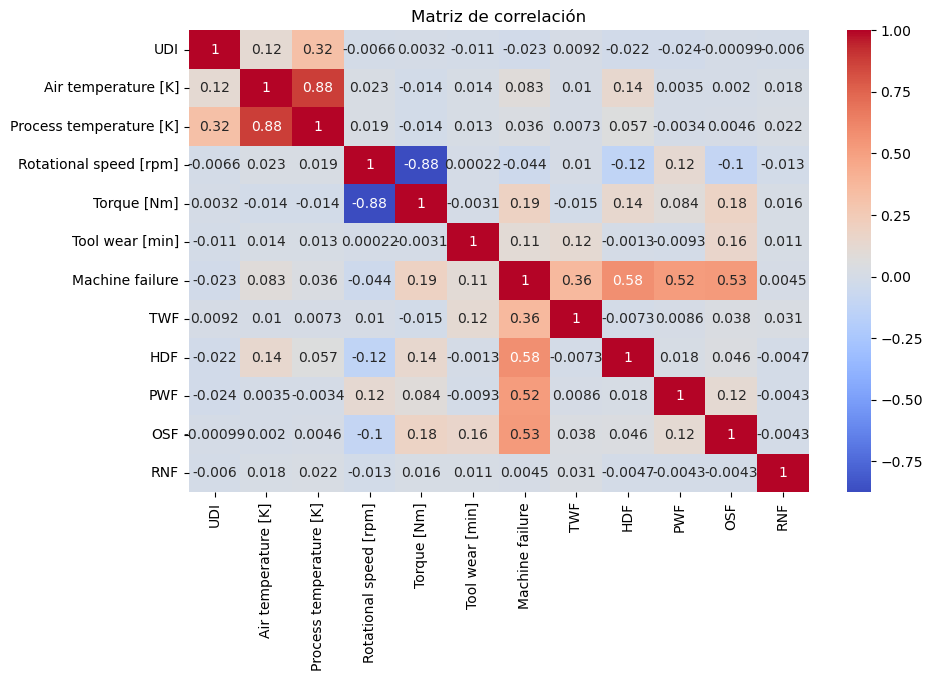

In [4]:
df_numeric = df.select_dtypes(include=["number"])

plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

### Conclusiones del Análisis Exploratorio

A partir de la matriz de correlación, se identifican relaciones relevantes entre las variables del dataset.
Se observa una alta correlación positiva entre la temperatura del aire y la temperatura del proceso, lo que sugiere que ambas variables representan condiciones operativas similares.

Asimismo, se evidencia una fuerte correlación negativa entre la velocidad de rotación y el torque, lo cual resulta coherente con el comportamiento esperado de este tipo de equipos.

En relación con la variable objetivo, se observa que variables como el torque y el desgaste de la herramienta presentan correlaciones positivas, aunque de magnitud moderada. Esto indica que, si bien no existe una relación lineal fuerte, estas variables pueden aportar información relevante para la predicción de fallas en modelos más complejos.

Por otro lado, las variables asociadas a tipos específicos de fallas presentan una alta correlación con la variable objetivo, lo que confirma que derivan directamente de esta. Por este motivo, fueron excluidas del modelado para evitar sesgos en los resultados.

## Limpieza y Preparación de Datos

In [21]:
df = df.drop(["Type", "Product ID", "UDI"], axis=1, errors="ignore")


Se eliminaron las variables Product ID y UDI debido a que corresponden a identificadores y no aportan información relevante para el modelo.

Asimismo, se excluyó la variable Type por ser categórica, asegurando que el conjunto de datos utilizado contenga únicamente variables numéricas compatibles con los algoritmos de aprendizaje automático.

## Preparación de los Datos

In [22]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Se separaron las variables independientes (X) de la variable objetivo (y), y se dividió el dataset en conjuntos de entrenamiento y prueba.
Esto permite evaluar la capacidad del modelo para generalizar sobre datos no vistos.

## Normalización de los Datos

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Se aplicó una normalización de los datos para asegurar que todas las variables se encuentren en la misma escala, evitando que aquellas con valores más grandes influyan de manera desproporcionada en el modelo.

## Modelado: Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Evaluación del Modelo


In [36]:
from sklearn.metrics import classification_report

y_pred = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



El modelo Random Forest presenta un desempeño excelente en la predicción de fallas, alcanzando un alto nivel de precisión y exactitud en la clasificación.

Se observa que el modelo logra identificar correctamente la totalidad de los casos sin falla, mientras que en la detección de fallas alcanza un recall de 0.97, lo que indica una alta capacidad para detectar eventos críticos.

Este resultado es especialmente relevante en contextos de soporte técnico, donde no anticipar una falla puede generar impactos operativos significativos. En este sentido, el modelo demuestra ser eficaz para minimizar falsos negativos, lo cual resulta clave en la implementación de estrategias de mantenimiento preventivo.

A pesar del desbalance en el dataset, el modelo logra mantener un rendimiento sólido, lo que evidencia su capacidad para generalizar y capturar patrones relevantes en los datos.

## Conclusiones

En conclusión, el modelo desarrollado no solo permite predecir fallas con un alto grado de precisión, sino que también constituye una herramienta útil para la toma de decisiones en entornos de soporte técnico.

Su aplicación permite anticipar problemas, priorizar intervenciones y optimizar la planificación del mantenimiento, contribuyendo a una mejora en la eficiencia operativa y la disponibilidad de los equipos.